In [5]:
# --- 必要なパッケージ ---
library(caret)
library(Metrics)
library(ggplot2)
library(lattice)
library(earth)
library(dplyr)

# --- OOD分割関数 (変更なし) ---
create_ood_split <- function(df, feature_cols, ood_ratio = 0.1) {
    df_features <- df[, feature_cols, drop = FALSE] 
    dist_matrix <- dist(df_features, method = "euclidean")
    avg_distances <- as.matrix(dist_matrix) %>% colMeans()
    num_ood <- floor(nrow(df) * ood_ratio)
    if (num_ood == 0 && nrow(df) > 0) num_ood <- 1 
    ood_indices <- order(avg_distances, decreasing = TRUE)[1:num_ood]
    test_set <- df[ood_indices, ]
    train_set <- df[-ood_indices, ]
    cat(paste0("  OOD Split: Total=", nrow(df), ", Train=", nrow(train_set), ", Test(OOD)=", nrow(test_set), "\n"))
    return(list(train = train_set, test = test_set, ood_indices = ood_indices))
}

# --- 設定 ---
file_names <- c(
    "n_base.csv", "n_base_OH.csv", "n_base_FP.csv",
    "n_all.csv", "n_all_OH.csv", "n_all_FP.csv",
    "m_base.csv", "m_base_OH.csv", "m_base_FP.csv",
    "m_all.csv", "m_all_OH.csv", "m_all_FP.csv"
)

# 除去する列のリスト (IDとして特定された X を指定)
excluded_cols <- c("X") 

base_path <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/"
today <- format(Sys.Date(), "%Y%m%d")
target_vars <- c("Jsc", "Voc", "FF", "PCEmax")
metric_names <- c("Best_degree", "R2", "RMSE", "MAE", "RPD", "n_samples", "n_features", "OOD_R2", "OOD_RMSE") 

result_matrix <- matrix(nrow = length(metric_names) * length(target_vars), ncol = length(file_names))
rownames(result_matrix) <- as.vector(t(outer(metric_names, target_vars, paste, sep = "_")))
colnames(result_matrix) <- file_names

# --- メインループ ---
for (file in file_names) {
    filepath <- paste0(base_path, file)
    cat("\n=== Processing:", file, " (Excluding ID: X) ===\n")
    
    # 1. データの読み込み
    df_all <- read.csv(filepath)
    
    # 【重要修正】ID列（X）が存在すれば即座に削除
    df_all <- df_all[, setdiff(colnames(df_all), excluded_cols), drop = FALSE]
    
    # 2. ターゲット変数以外を初期特徴量とする
    feature_vars_initial <- setdiff(colnames(df_all), target_vars)

    for (target_var in target_vars) {
        cat("\n--- Training for:", target_var, " ---\n")

        # --- 前処理 ---
        df_temp <- df_all[, c(feature_vars_initial, target_var)]
        df_temp <- df_temp[complete.cases(df_temp), ]
        df_temp <- df_temp[, sapply(df_temp, is.numeric)]
        nzv <- nearZeroVar(df_temp, saveMetrics = TRUE)
        df_complete <- df_temp[, !(nzv$zeroVar | nzv$nzv)]
        
        feature_vars_final <- setdiff(colnames(df_complete), target_var)

        if (nrow(df_complete) < 20 || length(feature_vars_final) == 0) {
            cat("  Skipping: insufficient data or features.\n")
            next
        }

        # === 3. OOD分割 (FPデータのみ、Xを含まない特徴量で行う) ===
        is_fp_data <- grepl("_FP\\.csv$", file) 
        if (is_fp_data) {
            cat("  Performing OOD split based on pure structural distance...\n")
            split_list <- create_ood_split(df_complete, feature_vars_final, ood_ratio = 0.1) 
            df_train_cv <- split_list$train
            df_ood_test <- split_list$test
        } else {
            df_train_cv <- df_complete
            df_ood_test <- NULL
        }

        # === 4. gcvEarthモデルの訓練 ===
        ctrl <- trainControl(method = "cv", number = 10, savePredictions = "final")
        tune_grid <- expand.grid(degree = 1:3)

        model <- train(
            formula(paste(target_var, "~ .")),
            data = df_train_cv,
            method = "gcvEarth",
            metric = "RMSE",
            trControl = ctrl,
            tuneGrid = tune_grid
        )

        # === 5. 結果の計算と格納 ===
        pred <- predict(model, df_train_cv)
        obs <- df_train_cv[[target_var]]

        R2 <- round(cor(pred, obs)^2, 3)
        RMSE_val <- round(rmse(obs, pred), 3)
        MAE_val <- round(mae(obs, pred), 3)
        RPD_val <- round(sd(obs) / RMSE_val, 3)

        result_matrix[paste0("Best_degree_", target_var), file] <- model$bestTune$degree
        result_matrix[paste0("R2_", target_var), file] <- R2
        result_matrix[paste0("RMSE_", target_var), file] <- RMSE_val
        result_matrix[paste0("MAE_", target_var), file] <- MAE_val
        result_matrix[paste0("RPD_", target_var), file] <- RPD_val
        result_matrix[paste0("n_samples_", target_var), file] <- nrow(df_complete)
        result_matrix[paste0("n_features_", target_var), file] <- length(feature_vars_final)
        
        # OOD性能
        if (is_fp_data && !is.null(df_ood_test) && nrow(df_ood_test) > 0) {
            ood_preds <- predict(model, newdata = df_ood_test)
            ood_obs <- df_ood_test[[target_var]]
            ood_R2 <- round(cor(ood_obs, ood_preds)^2, 3)
            ood_RMSE_val <- round(rmse(ood_obs, ood_preds), 3)
            result_matrix[paste0("OOD_R2_", target_var), file] <- ood_R2
            result_matrix[paste0("OOD_RMSE_", target_var), file] <- ood_RMSE_val
        } else {
            result_matrix[paste0("OOD_R2_", target_var), file] <- NA
            result_matrix[paste0("OOD_RMSE_", target_var), file] <- NA
        }

        # === 6. モデルの保存 (識別のためファイル名に fixed_ を追加) ===
        model_data_bundle <- list(model = model, training_data = df_train_cv, ood_test_data = df_ood_test)
        rds_file <- paste0("fixed20250702_model_data_gcvEarth_", tools::file_path_sans_ext(file), "_", target_var, "_", today, ".rds")
        saveRDS(model_data_bundle, file = rds_file)
    }
}

# --- 最終サマリーの保存 ---
output_file <- paste0("fixed20250702_gcvEarth_summary_", today, ".csv")
write.csv(result_matrix, output_file, row.names = TRUE)
cat("\n✅ Fixed Summary saved as:", output_file, "\n")


=== Processing: n_base.csv  (Excluding ID: X) ===

--- Training for: Jsc  ---

--- Training for: Voc  ---

--- Training for: FF  ---

--- Training for: PCEmax  ---

=== Processing: n_base_OH.csv  (Excluding ID: X) ===

--- Training for: Jsc  ---

--- Training for: Voc  ---

--- Training for: FF  ---

--- Training for: PCEmax  ---

=== Processing: n_base_FP.csv  (Excluding ID: X) ===

--- Training for: Jsc  ---
  Performing OOD split based on pure structural distance...
  OOD Split: Total=358, Train=323, Test(OOD)=35

--- Training for: Voc  ---
  Performing OOD split based on pure structural distance...
  OOD Split: Total=358, Train=323, Test(OOD)=35

--- Training for: FF  ---
  Performing OOD split based on pure structural distance...
  OOD Split: Total=358, Train=323, Test(OOD)=35

--- Training for: PCEmax  ---
  Performing OOD split based on pure structural distance...
  OOD Split: Total=358, Train=323, Test(OOD)=35

=== Processing: n_all.csv  (Excluding ID: X) ===

--- Training for

In [3]:
# --- 1. ファイルを直接読み込む ---
# ※パスは先ほど成功したものを指定してください
target_path <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/OOD_check/gcvEarth/new20250702_model_data_gcvEarth_n_base_FP_PCEmax_20251212.rds"

if (!file.exists(target_path)) {
    stop("ファイルが見つかりません。パスを確認してください。")
}

# データのロード
bundle_check <- readRDS(target_path)

# --- 2. 変数 X の値を抽出して表示 ---
cat("==========================================\n")
cat("  変数 'X' の正体を確認します\n")
cat("==========================================\n\n")

# 学習データ
if ("X" %in% colnames(bundle_check$training_data)) {
    cat("--- 学習データ (Train) の X (10件) ---\n")
    print(head(bundle_check$training_data$X, 10))
} else {
    cat("学習データに変数 'X' は存在しません。\n")
}

cat("\n------------------------------------------\n")

# OODテストデータ
if ("X" %in% colnames(bundle_check$ood_test_data)) {
    cat("--- OODテストデータ (Test) の X (10件) ---\n")
    print(head(bundle_check$ood_test_data$X, 10))
} else {
    cat("OODテストデータに変数 'X' は存在しません。\n")
}

# 3. 統計的なヒント
if ("X" %in% colnames(bundle_check$training_data)) {
    cat("\n------------------------------------------\n")
    cat("値の範囲:", range(bundle_check$training_data$X, na.rm=TRUE), "\n")
    cat("重複のないユニークな値の数:", length(unique(bundle_check$training_data$X)), "\n")
}

  <U+5909><U+6570> 'X' <U+306E><U+6B63><U+4F53><U+3092><U+78BA><U+8A8D><U+3057><U+307E><U+3059>

--- <U+5B66><U+7FD2><U+30C7><U+30FC><U+30BF> (Train) <U+306E> X (10<U+4EF6>) ---
 [1] 256 257 258 259 260 261 262 263 264 265

------------------------------------------
--- OOD<U+30C6><U+30B9><U+30C8><U+30C7><U+30FC><U+30BF> (Test) <U+306E> X (10<U+4EF6>) ---
 [1] 1048 1047 1046 1045 1044 1043 1042 1041 1040 1039

------------------------------------------
<U+5024><U+306E><U+7BC4><U+56F2>: 256 982 
<U+91CD><U+8907><U+306E><U+306A><U+3044><U+30E6><U+30CB><U+30FC><U+30AF><U+306A><U+5024><U+306E><U+6570>: 323 


<U+2705> <U+5909><U+6570> 'X' <U+3092><U+9664><U+5916><U+3057><U+305F><U+518D><U+5B66><U+7FD2><U+304C><U+5B8C><U+4E86><U+3057><U+307E><U+3057><U+305F><U+3002>
              nsubsets   gcv    rss
Mmonomerp1M         34  74.4   79.1
MnkDap1M            30 100.0> 100.0>
HOMOp1M             29  50.1   57.8
MwkDap1M            29  50.1   57.8
X85.4               29  50.1   57.8
X111.4              29  50.1   57.8
X125.4              29  50.1   57.8
X142.4              28  45.3   53.8
PDIp1M              26  38.2   48.0
X127.4              25  71.3>  74.3>
LUMOp1M             22  30.5   40.8
Egoptp1M            20  27.4   37.8
X98.4               19  38.6>  45.7>
X163.4               9   6.2   20.3
X138.4               6   6.3   16.7
X42.4-unused         3  37.8>  37.2>
X135.4-unused        2  27.4   27.3
X20.4-unused         1  14.3   15.3


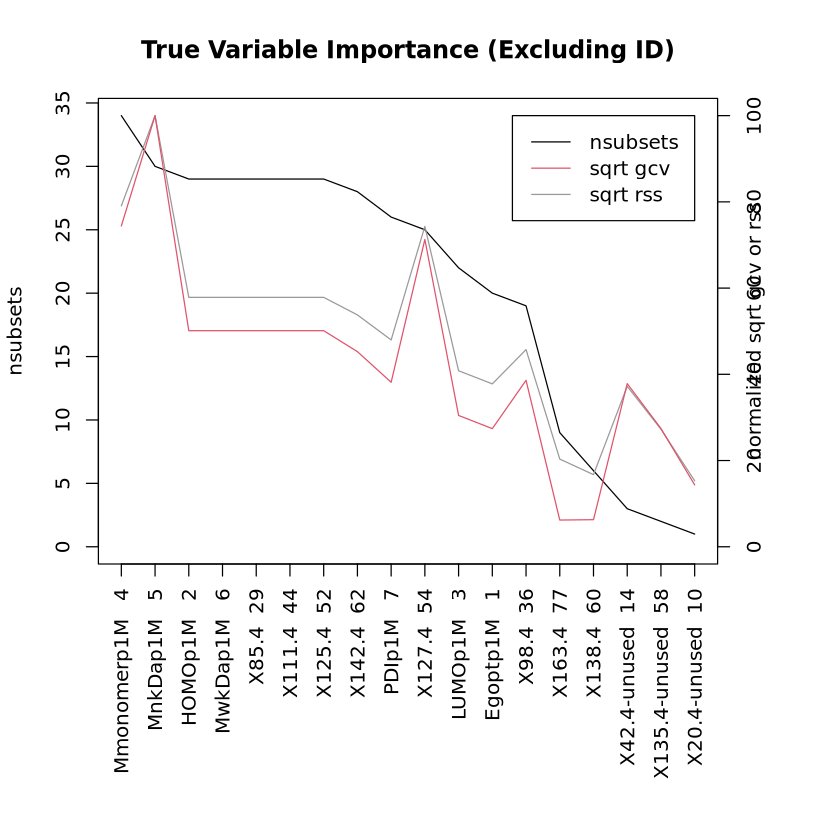

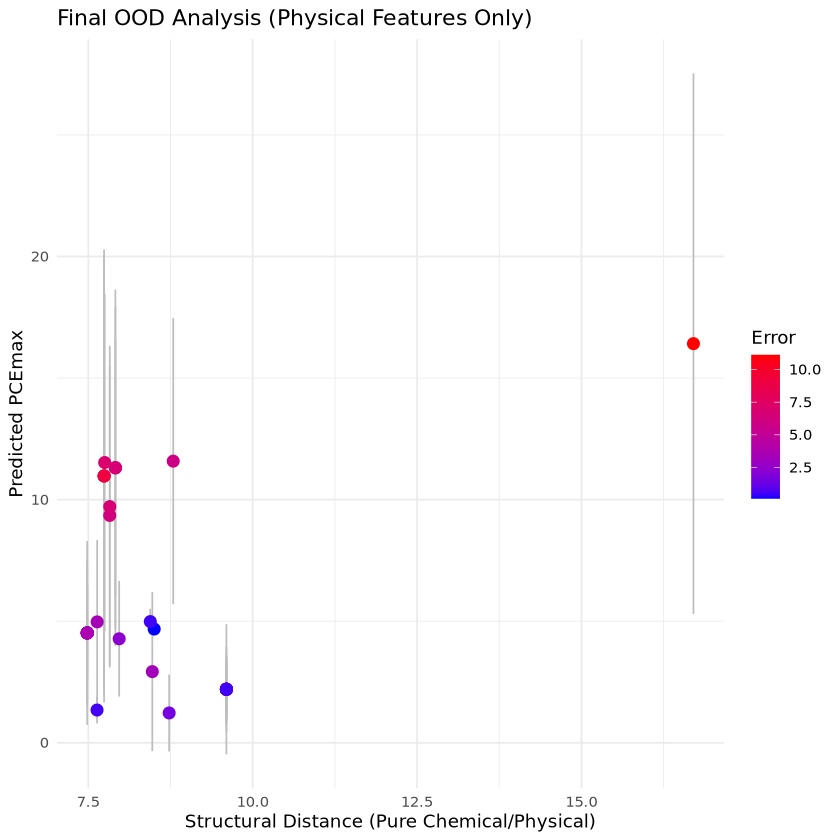

In [4]:
# ==============================================================================
# 変数 X (ID) を除外した、真の重要度解析コード
# ==============================================================================

library(earth)
library(ggplot2)

# 1. データの再読み込みと除外処理
# ※パスはご自身の環境に合わせてください
target_path <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/OOD_check/gcvEarth/new20250702_model_data_gcvEarth_n_base_FP_PCEmax_20251212.rds"
bundle <- readRDS(target_path)

# --- 重要：ID列(X)を除外してデータをクリーンにする ---
clean_train <- bundle$training_data[, setdiff(colnames(bundle$training_data), "X")]
clean_ood   <- bundle$ood_test_data[, setdiff(colnames(bundle$ood_test_data), "X")]
target <- "PCEmax"

# 2. モデルの再構築（caretを使わず直接earthで構築すると重要度解析がスムーズです）
# bundle$model$bestTune$degree を使って最適パラメータを継承
final_earth_model <- earth(
  formula = as.formula(paste(target, "~ .")),
  data    = clean_train,
  degree  = bundle$model$bestTune$degree
)

cat("✅ 変数 'X' を除外した再学習が完了しました。\n")

# 3. 真の変数重要度の抽出
ev_final <- evimp(final_earth_model)
print(ev_final)
plot(ev_final, main = "True Variable Importance (Excluding ID)")

# 4. 不確実性の再プロット（真の物理的距離に基づく）
preds_final <- predict(final_earth_model, newdata = clean_ood)
actuals_ood <- clean_ood[[target]]
errors_final <- abs(as.numeric(preds_final) - as.numeric(actuals_ood))

# 距離計算
center_final <- colMeans(clean_train[, final_earth_model$namesx])
dist_final   <- apply(clean_ood[, final_earth_model$namesx], 1, function(x) sqrt(sum((x - center_final)^2)))

df_final_viz <- data.frame(Distance = dist_final, Prediction = as.numeric(preds_final), Error = errors_final)

ggplot(df_final_viz, aes(x = Distance, y = Prediction)) +
  geom_errorbar(aes(ymin = Prediction - Error, ymax = Prediction + Error), color = "gray") +
  geom_point(aes(color = Error), size = 3) +
  scale_color_gradient(low = "blue", high = "red") +
  theme_minimal() +
  labs(title = "Final OOD Analysis (Physical Features Only)",
       x = "Structural Distance (Pure Chemical/Physical)", y = "Predicted PCEmax")